# Estimate $k_F$ and $k_M$

## 1. Set up the notebook

Do imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ae483.tools import *
from ae483.mytools import *

## 2. Define constants

Define the acceleration of gravity in $\text{m} \;/\; \text{s}^2$:

In [2]:
g = 9.81

Define the mass of the drone in $\text{kg}$:

In [3]:
m = .034 # <-- fixed

Define the principle moment of inertia about the $z$ axis in $\text{kg}\cdot\text{m}^2$:

In [4]:
J_z = 4.42e-5 # <-- fixed

Using a ruler, measure the distance $\ell$ in **meters** along both the $x_B$ and $y_B$ axis from the center of mass to the center of each rotor. The position of the front-right rotor, for example, would then be expressed in the coordinates of the body-frame as

$$p^B_1 = \begin{bmatrix} \ell \\ -\ell \\ 0 \end{bmatrix}.$$

In [5]:
l = .045 #in m # <-- fixed

## 3. Find the force parameter

### 3.1 Describe the flight

**Modify the text in this cell** to give a precise description of the flight trajectory, both in words and with the relevant code from `flight.py` (i.e., the sequence of stop and move commands). Please include code in markdown with a "code block" that is delimited by three backslashes above and below — for example, this...

``````
```python
drone_client.move(0.0, 0.0, 0.5, 0.0, 1.0)
```
``````
...is rendered like this:
```python
drone_client.move(0.0, 0.0, 0.5, 0.0, 1.0)
```

### 3.2 Get and plot flight data

Load and resample data.

In [51]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('force_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=5.,    # <-- Fixed
    t_max_offset=3.,    # <-- Fixed
)

Parse data to get:
* time
* the accelerometer measurements (**note!** these are in units of "$g$'s")
* the motor power commands

In [52]:
t = data_drone['time']
a_x = g * data_drone['acc.x']
a_y = g * data_drone['acc.y']
a_z = g * data_drone['acc.z']
m_1 = data_drone['motor.m1']
m_2 = data_drone['motor.m2']
m_3 = data_drone['motor.m3']
m_4 = data_drone['motor.m4']

Plot accelerometer measurements and motor power commands, and check three things:
* Check that the $x$ and $y$ accelerometer measurements are much smaller than the $z$ accelerometer measurements. We would expect this to be true, because the rotors generate force only in the body-fixed $z$ direction. If this is not true, then something is wrong — fix the problem before going any further.
* Check that all four motor power commands are approximately the same. If this is not true, then either the mass on your drone is unbalanced (e.g., the battery may be out of place) or some of the motors (or rotors) on your drone may be damaged — fix the problem before going any further.
* Check that you are only seeing data from when the drone was *actually flying*. If this is not true, go back and adjust `t_min_offset` and `t_max_offset`.

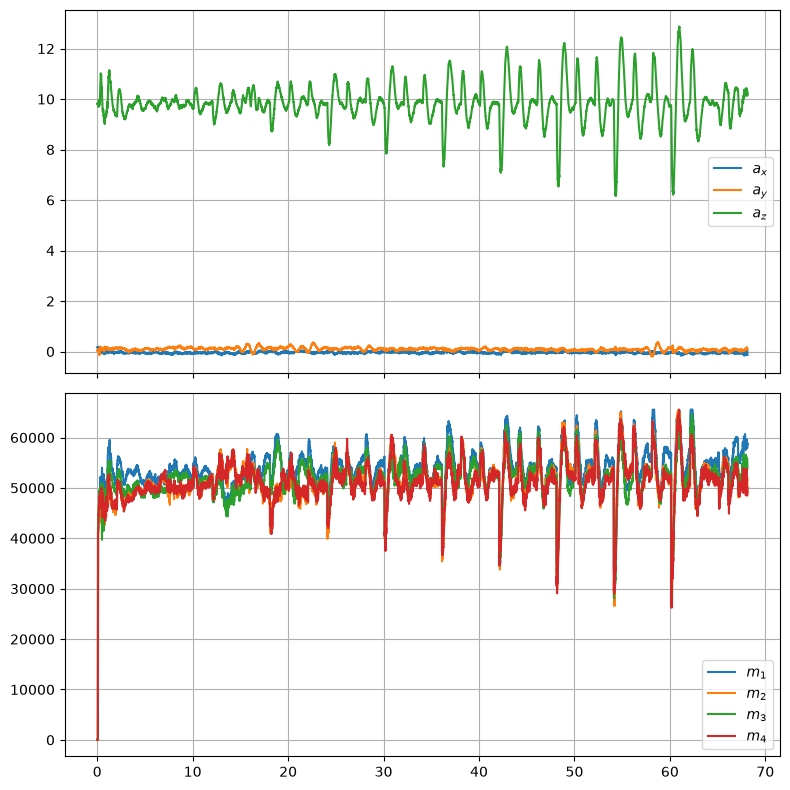

In [53]:
fig, (ax_a, ax_m) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, tight_layout=True)
ax_a.plot(t, a_x, label=r'$a_x$')
ax_a.plot(t, a_y, label=r'$a_y$')
ax_a.plot(t, a_z, label=r'$a_z$')
ax_a.legend()
ax_a.grid()
ax_m.plot(t, m_1, label=r'$m_1$')
ax_m.plot(t, m_2, label=r'$m_2$')
ax_m.plot(t, m_3, label=r'$m_3$')
ax_m.plot(t, m_4, label=r'$m_4$')
ax_m.legend()
ax_m.grid()

### 3.3 Apply linear regression to estimate $k_F$ and $T_F$

Write a function to estimate $k_F$ for a given $T_F$.

In [54]:
def estimate_force_parameter(T_F):
    # Compute x(t)
    x = m_1+m_2+m_3+m_4 # <-- fixed
    
    # Compute y(t)
    y = m*a_z # <-- fixed

    # Compute y(t + T_F)
    y = np.interp(t + T_F, t, y)

    # Compute estimate
    k_F = np.dot(x,y) / np.dot(x,x) # <-- fixed

    # Compute RMSE
    RMSE = np.sqrt(np.mean((y - k_F * x)**2))

    return k_F, RMSE, x, y

Find the RMSE for a range of $T_F$.

In [55]:
# Create an array with a range of T_F's
T_Fs = np.linspace(0., 0.2, 401)

# Create an array to hold the RMSE for each T_F
RMSEs = np.empty_like(T_Fs)

# Find the RMSE for each T_F
for i, T_F in enumerate(T_Fs):
    k_F, RMSEs[i], x, y = estimate_force_parameter(T_F)

Find the value of $T_F$ that gives the minimum RMSE.

In [56]:
# Find the index of the minimum RMSE
i = np.argmin(RMSEs)           # <-- fixed

# Find the minimum RMSE
RMSE = np.min(RMSEs)       # <-- fixed

# Find the time shift that gives the minimum RMSE
T_F = T_Fs[i]    # <-- fixed

Plot the RMSE for a range of $T_F$, showing the minimum.

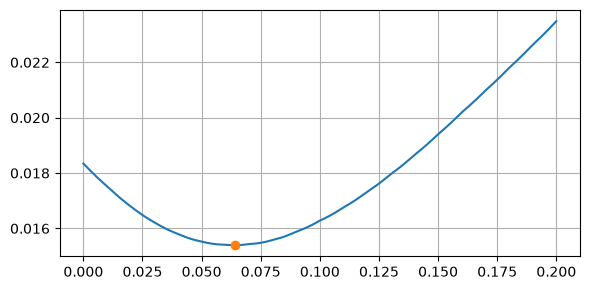

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(T_Fs, RMSEs)
ax.plot(T_F, RMSE, '.', markersize=12)
ax.grid()

Recompute the estimate of $k_F$ for the value of $T_F$ that results in minimum RMSE.

In [58]:
k_F, RMSE, x, y = estimate_force_parameter(T_F)

Show the estimate.

In [59]:
print(f'k_F = {k_F:.2e}')
print(f'T_F = {T_F:.3f}')

k_F = 1.60e-06
T_F = 0.064


### 3.4 Validate your estimate

Show a plot that compares the predicted value of $f_z$ (i.e., $k_F x(t)$) with the measured value of $f_Z$ (i.e., $y(t + T_F)$), both as functions of $t$.

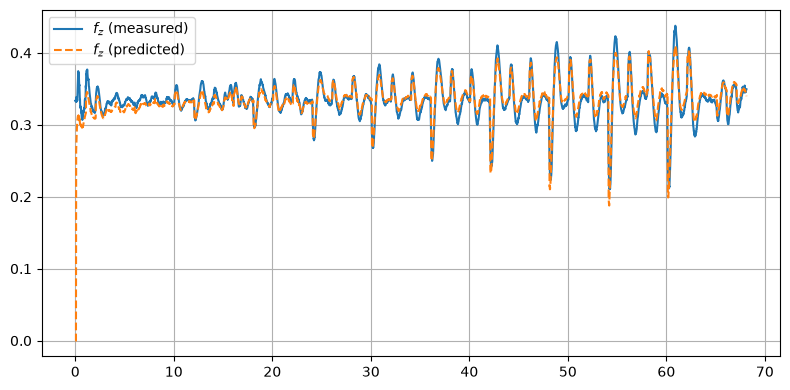

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, y, label=r'$f_z$ (measured)')
ax.plot(t, k_F * x, '--', label=r'$f_z$ (predicted)')
ax.legend()
ax.grid()

Show a plot that compares the linear fit (i.e., $k_F x(t)$) to the raw data (i.e., $y(t + T_F)$), both as functions of $x(t)$.

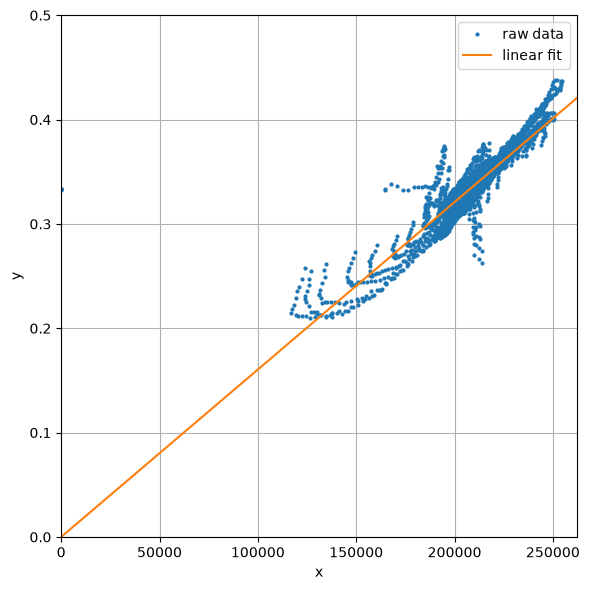

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), tight_layout=True)
ax.plot(x, y, '.', markersize=4, label='raw data')
ax.plot([0, 262140], [k_F * 0, k_F * 262140], label='linear fit')
ax.set_xlim(0, 262140)
ax.set_xlabel('x')
ax.set_ylim(0, 0.5)
ax.set_ylabel('y')
ax.legend()
ax.grid()

## 4. Find the moment parameter

### 4.1 Describe the flight

**Modify the text in this cell** to give a precise description of the flight trajectory, both in words and with the relevant code from `flight.py` (i.e., the sequence of stop and move commands). Please include code in markdown with a "code block" that is delimited by three backslashes above and below — for example, this...

``````
```python
drone_client.move(0.0, 0.0, 0.5, 0.0, 1.0)
```
``````
...is rendered like this:
```python
drone_client.move(0.0, 0.0, 0.5, 0.0, 1.0)
```

### 4.2 Get and plot flight data

Load and resample data.

In [62]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('moment_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=3.,    # <-- fixed
    t_max_offset=5.,    # <-- fixed
)

Parse data to get:
* time
* the gyroscope measurements (**note!** these are in units of degrees / second)
* the motor power commands

In [63]:
t = data_drone['time']
w_x = np.deg2rad(data_drone['gyro.x'])
w_y = np.deg2rad(data_drone['gyro.y'])
w_z = np.deg2rad(data_drone['gyro.z'])
m_1 = data_drone['motor.m1']
m_2 = data_drone['motor.m2']
m_3 = data_drone['motor.m3']
m_4 = data_drone['motor.m4']

Find the time step. It should be `0.01` because data were sampled at 100 Hz. (If it is not, stop and fix the problem.)

In [64]:
dt = t[1] - t[0]
print(f'dt = {dt}')

dt = 0.01


Plot gyroscope measurements and motor power commands, and check two things:
* Check that the $x$ and $y$ gyroscope measurements are much smaller than the $z$ gyroscope measurements. We would expect this to be true, because the drone was near hover during flight (only yawing back and forth). If this is not true, then something is wrong — fix the problem before going any further.
* Check that you are only seeing data from when the drone was *actually flying*. If this is not true, go back and adjust `t_min_offset` and `t_max_offset`.

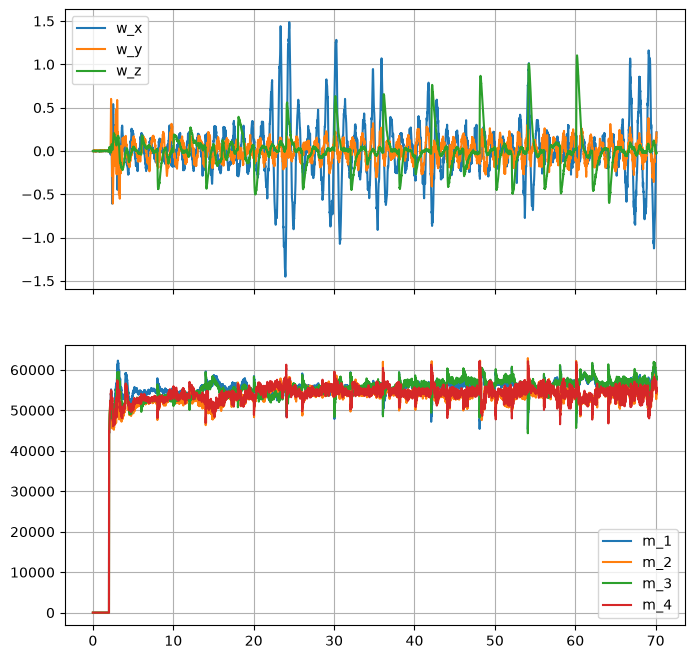

In [65]:
fig, (ax_w, ax_m) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax_w.plot(t, w_x, label='w_x')
ax_w.plot(t, w_y, label='w_y')
ax_w.plot(t, w_z, label='w_z')
ax_w.legend()
ax_w.grid()
ax_m.plot(t, m_1, label='m_1')
ax_m.plot(t, m_2, label='m_2')
ax_m.plot(t, m_3, label='m_3')
ax_m.plot(t, m_4, label='m_4')
ax_m.legend()
ax_m.grid()

### 4.3 Use finite difference to estimate $\dot{w}_z$

Estimate $\dot{w}_z$ by finite difference.

In [69]:
w_z_dot = np.gradient(w_z, dt) # <-- fixed (REPLACE WITH CODE TO COMPUTE W_Z_DOT BY FINITE DIFFERENCE)

Truncate all other data so that everything has the same length.

In [70]:
# Truncate data so everything has the same length
mask = t >= t.min() + 3.

t = t[mask]
w_x = w_x[mask]
w_y = w_y[mask]
w_z = w_z[mask]
w_z_dot = w_z_dot[mask]
m_1 = m_1[mask]
m_2 = m_2[mask]
m_3 = m_3[mask]
m_4 = m_4[mask]

Plot both $w_z$ and $\dot{w}_z$ as a check to make sure finite difference was implemented correctly. (What should the sign of $\dot{w}_z$ be when $w_z$ is increasing, for example?)

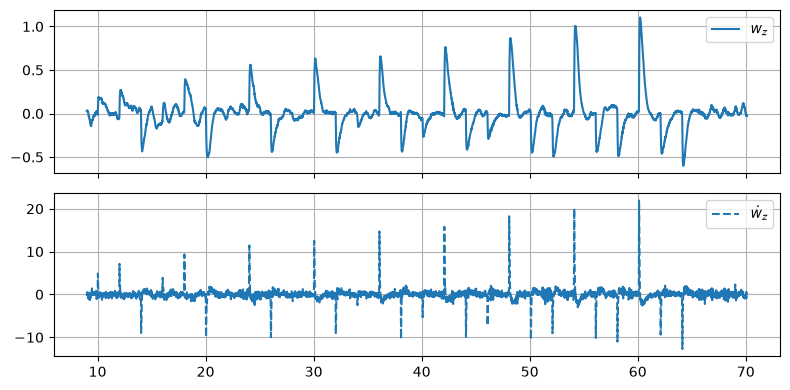

In [71]:
fig, (ax_w_z, ax_w_z_dot) = plt.subplots(2, 1, figsize=(8, 4), sharex=True, tight_layout=True)
ax_w_z.plot(t, w_z, label=r'$w_z$')
ax_w_z.legend()
ax_w_z.grid()
ax_w_z_dot.plot(t, w_z_dot, '--', label=r'$\dot{w}_z$')
ax_w_z_dot.legend()
ax_w_z_dot.grid()

### 4.4 Apply linear regression to estimate $k_M$ and $T_M$

Write a function to estimate $k_M$ for a given $T_M$.

In [72]:
def estimate_kM(T_M):
    # Compute x(t)
    x = -m_1+m_2-m_3+m_4 # <-- FIXME
    
    # Compute y(t)
    y = J_z*w_z_dot # <-- FIXME
    
    # Compute y(t + T_M)
    y = np.interp(t + T_M, t, y)

    # Compute estimate
    k_M = np.dot(x, y) / np.dot(x, x) # <-- FIXME
    
    # Compute RMSE
    RMSE = np.sqrt(np.mean((y - k_M * x)**2))

    return k_M, RMSE, x, y

Find the RMSE for a range of $T_M$.

In [73]:
# Create an array with a range of T's
T_Ms = np.linspace(0., 0.2, 401)

# Create an array to hold the RMSE for each T
RMSEs = np.empty_like(T_Ms)

# Find the RMSE for each T_M
for i, T_M in enumerate(T_Ms):
    k_M, RMSEs[i], x, y = estimate_kM(T_M)

Find the value of $T_M$ that gives the minimum RMSE.

In [74]:
# Find the index of the minimum RMSE
i = np.argmin(RMSEs)          # <-- FIXME

# Find the minimum RMSE
RMSE = RMSEs[i]       # <-- FIXME

# Find the time shift that gives the minimum RMSE
T_M = T_Ms[i]        # <-- FIXME

Plot the RMSE for a range of $T_M$, showing the minimum.

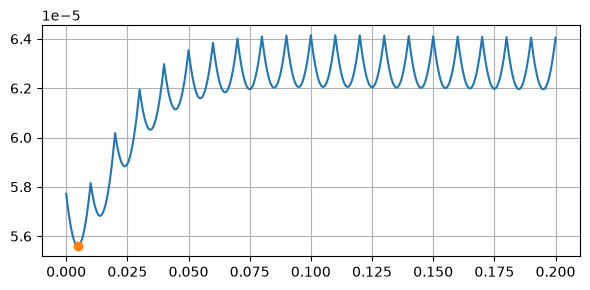

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(T_Ms, RMSEs)
ax.plot(T_M, RMSE, '.', markersize=12)
ax.grid()

Recompute the estimate of $k_F$ for the value of $T_M$ that results in minimum RMSE.

In [76]:
k_M, RMSE, x, y = estimate_kM(T_M)

Show the estimate.

In [77]:
print(f'k_M = {k_M:.2e}')
print(f'T_M = {T_M:.3f}')

k_M = 4.61e-09
T_M = 0.005


### 4.5 Validate your estimate

Show a plot that compares the predicted value of $\tau_z$ (i.e., $k_M x(t)$) with the measured value of $\tau_Z$ (i.e., $y(t + T_M)$), both as functions of $t$.

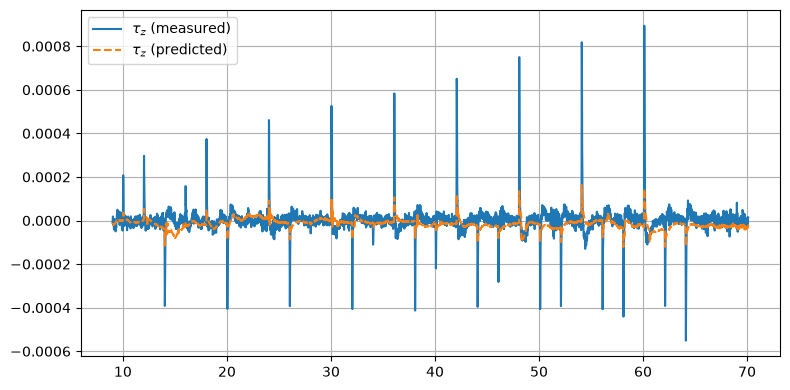

In [78]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, y, label=r'$\tau_z$ (measured)')
ax.plot(t, k_M * x, '--', label=r'$\tau_z$ (predicted)')
ax.legend()
ax.grid()

Show a plot that compares the linear fit (i.e., $k_M x$ versus $x$) to the raw data (i.e., $y(t + T_M)$ versus $x(t)$).

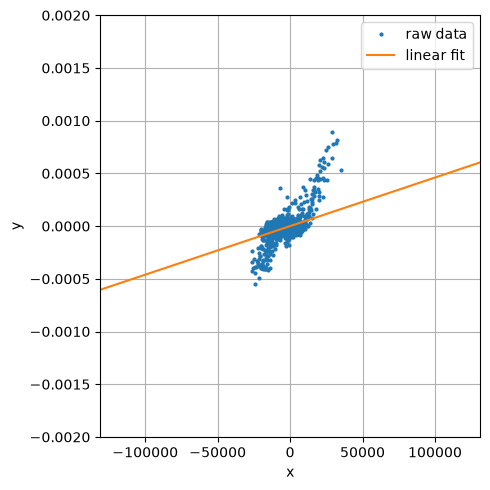

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), tight_layout=True)
ax.plot(x, y, '.', markersize=4, label='raw data')
ax.plot([-131070, 131070], [k_M * -131070, k_M * 131070], label='linear fit')
ax.set_xlim(-131070, 131070)
ax.set_xlabel('x')
ax.set_ylim(-.002, 0.002)
ax.set_ylabel('y')
ax.legend()
ax.grid()

## 5. Summarize and discuss the results

### 5.1 Summary of results

In [80]:
print(f'l = {l:.3f} m')
print(f'k_F = {k_F:.2e} N  (T_F = {T_F:.3f} s)')
print(f'k_M = {k_M:.2e} N  (T_M = {T_M:.3f} s)')

l = 0.045 m
k_F = 1.60e-06 N  (T_F = 0.064 s)
k_M = 4.61e-09 N  (T_M = 0.005 s)


### 5.2 Conclusions about time delay

**Modify the text in this cell** to answer the following questions about your results:

* What is the delay between the time at which a motor command is given and the time at which the corresponding rotor produces a force along the $z_B$ axis? **0.064s**

* Do you consider this delay to be significant? **This time delay is more signifcant than that for moment, but the delay is expected when the drone needs to stablize from the constant up and down motion.**

* What is the delay between the time at which a motor command is given and the time at which the corresponding rotor produces a moment about the $z_B$ axis? **0.005s**

* Do you consider this delay to be significant? **No, 0.005s seems negligible**

Then, based on your answers to these first two questions, answer four more:

* What delay would you expect between the time at which your controller asks for a net torque $\tau_x$ and the time at which that torque is produced? Do you consider this delay to be significant? **The delay for the drone to roll once commanded will be signifcant. We expect it to be similar to that of pitch due to the stabilization needed for this control.**
* What delay would you expect between the time at which your controller asks for a net torque $\tau_y$ and the time at which that torque is produced? Do you consider this delay to be significant? **The delay for the drone to pitch once commanded will be signifcant. We expect it to be greater than that for yaw due to the needed stabilization for pitch to occur and remain flying.**
* What delay would you expect between the time at which your controller asks for a net torque $\tau_z$ and the time at which that torque is produced? Do you consider this delay to be significant? **The delay between the controller changing the yaw and the torque being produced is expected to be insigificant. For the drone to yaw only, the drone does not have to undergo excess stabilization before performing the control**
* What delay would you expect between the time at which your controller asks for a net force $f_z$ and the time at which that force is produced? Do you consider this delay to be significant? **We expect a negligible time delay for the chnage in force.**

Please justify your answers (don't just say "yes" or "no").

### 5.3 Sources of error

**Modify the text in this cell** to discuss possible sources of error. For example:

* How uncertain was each measurement and each computed quantity? **Measurement of the spar and mass are partially uncertain, and J_z has a certain level of uncertainty found in lab 3. We are however comfortable enough with the measurements that we have**
* What assumptions were made and to what extent were these assumptions violated? **the spar length l was assumed by taking one measurement and assuming  all lengths were the same. The distance from the center of mass was roughly estimated using a ruler based on where we believed the CoM would be. We also assumed all motors are identical and the force and torque in each motor is linearly proportional to the corresponding motor power command. These were not too heavily violated assuming our drone is not faulty.**

You may find that these questions are harder to answer than in the previous lab.

### 5.4 Ways to improve the results

**Modify the text in this cell** to propose at least one way in which the experiments or the analysis could be improved to get estimates of $k_F$ and $k_M$ (as well as $T_F$ and $T_M$) that are more accurate (i.e., less uncertain). You could suggest improvements to your current method of approach, but you are also welcome to suggest a completely different method of approach.

**Have a more certain way of measuring spar length, and CoM. The CoM is partially guesstimated since the battery may not sit perfect within the drone, and there's wires, plugs, and buttons on opposing ends on the drone which means CoM may be shifter. we used linear regression to estimate the force and motor coefficients, there may be a better, more accurate method for estimating.**

### 5.5 Reflection

Review the reflection you put in your Lab 3 notebook. **Modify the text in this cell** to answer the following three questions with at least one sentence each:
* What was your biggest struggle this week? Was it the same or different from last week? **We did not understand the instructions and had trouble figuring out in what manner our drone should be testing its yaw**
* What was the most important thing you learned this week? **Verify results with the TA as we progress through the assignment**
* How does what you learned this week relate to what you learned last week? **We learned both weeks that we should check our work, but now we know to ask for TA input as we progress**